# 🧠 Notebook 2 — Fondements des Réseaux Profonds (ADL)

**Master 1 Intelligence Artificielle — Université de Nouakchott (UN-FST) — 2026**
Groupe : Mohamed Salem Ebnou Oubeid (C34613) · Fatimata Issa Saw (C21304) · Oussama Sid'Ahmed Hedy (C34603)

---

Ce notebook couvre les **fondements mathématiques et pratiques** du Deep Learning,
de l'implémentation d'un MLP from scratch (NumPy) jusqu'à l'entraînement avec PyTorch.

## Table des matières
1. Imports et configuration
2. Fonctions d'activation — visualisation et comparaison
3. MLP from scratch — implémentation NumPy
4. Test sur le problème XOR
5. Entraînement sur le dataset Digits
6. Backpropagation — visualisation des gradients
7. Comparaison des optimiseurs (SGD / Momentum / Adam)
8. Dropout et régularisation
9. Gradient vanishing — visualisation
10. Entraînement avec PyTorch (optionnel)


## 1. Imports et configuration

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# PyTorch est optionnel — le notebook reste fonctionnel sans lui
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import DataLoader, TensorDataset
    HAS_TORCH = True
    print(f"✅ PyTorch {torch.__version__} disponible")
except ImportError:
    HAS_TORCH = False
    print("⚠️  PyTorch non installé — sections PyTorch ignorées (pip install torch)")

# Couleurs UN-FST
C_GREEN  = '#3A8E5B'
C_GOLD   = '#E8B608'
C_BLUE   = '#1ea8c4'
C_RED    = '#e74c3c'
C_PURPLE = '#9b59b6'

plt.rcParams.update({
    'figure.dpi': 100,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})
print("✅ Imports OK")


✅ PyTorch 2.11.0+cpu disponible
✅ Imports OK


## 2. Fonctions d'activation — visualisation et comparaison

Les fonctions d'activation introduisent la **non-linéarité** indispensable
au MLP pour apprendre des représentations complexes.

| Fonction | Formule | Dérivée | Usage typique |
|----------|---------|---------|---------------|
| Sigmoid  | $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(1-\sigma)$ | Sortie binaire |
| Tanh     | $\tanh(x)$ | $1 - \tanh^2$ | Couches cachées (LSTM) |
| ReLU     | $\max(0, x)$ | $\mathbb{1}[x>0]$ | Couches cachées (défaut) |
| GELU     | $x \cdot \Phi(x)$ | complexe | Transformers |


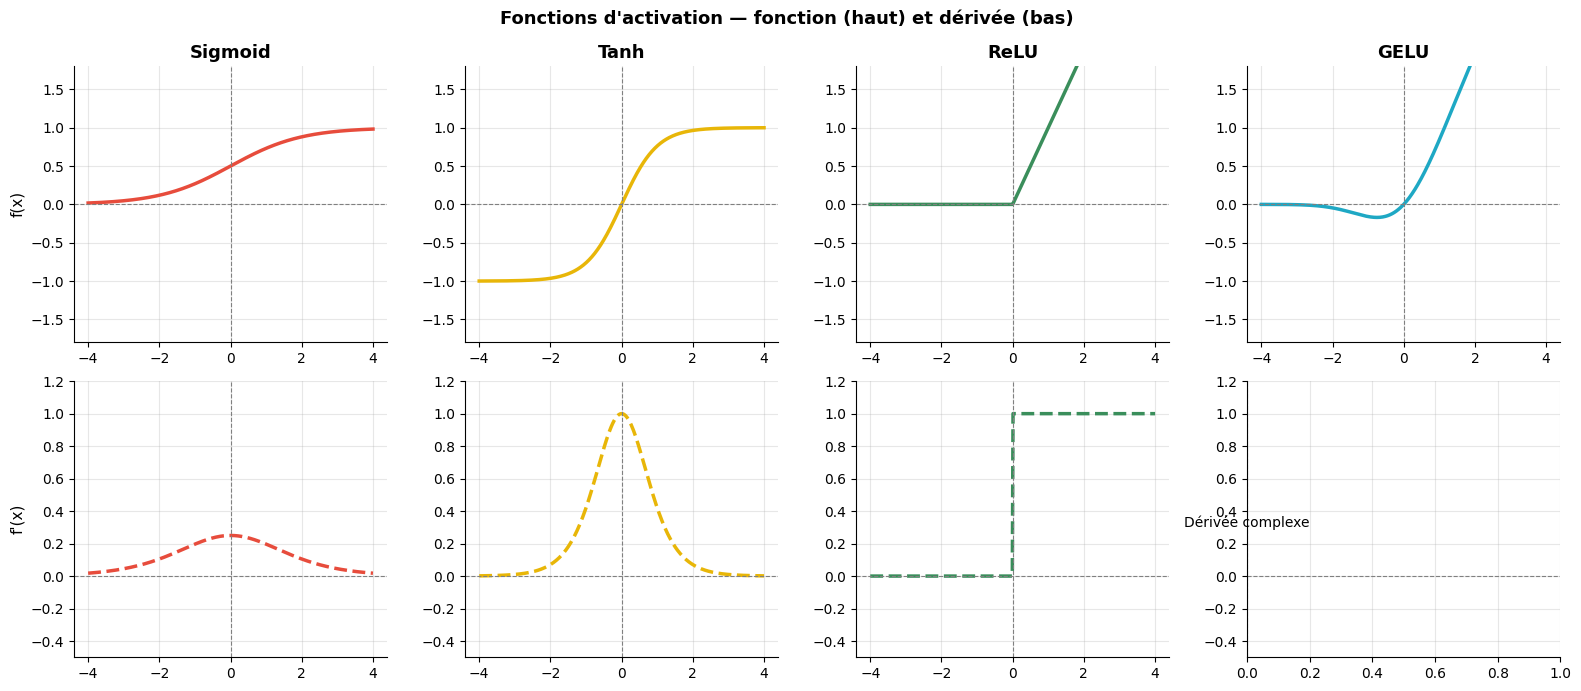

Observation clé : la dérivée de Sigmoid et Tanh est < 1 partout
→ lors de la backpropagation, les gradients s'amenuisent (vanishing gradient).
ReLU corrige cela : sa dérivée vaut 1 pour x > 0.


In [3]:
x = np.linspace(-4, 4, 400)

# Définition des fonctions et de leurs dérivées
def sigmoid(x):     return 1 / (1 + np.exp(-x))
def sigmoid_d(x):   s = sigmoid(x); return s * (1 - s)
def tanh_d(x):      return 1 - np.tanh(x) ** 2
def relu(x):        return np.maximum(0, x)
def relu_d(x):      return (x > 0).astype(float)
def gelu(x):
    # Approximation standard de GELU
    from scipy.special import ndtr
    return x * ndtr(x)

fonctions = {
    'Sigmoid':  (sigmoid(x),     sigmoid_d(x),  C_RED),
    'Tanh':     (np.tanh(x),     tanh_d(x),     C_GOLD),
    'ReLU':     (relu(x),        relu_d(x),     C_GREEN),
    'GELU':     (gelu(x),        None,          C_BLUE),
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, (nom, (vals, deriv, couleur)) in enumerate(fonctions.items()):
    # Ligne 0 : fonction
    axes[0, col].plot(x, vals, color=couleur, lw=2.5)
    axes[0, col].axhline(0, color='gray', lw=0.8, ls='--')
    axes[0, col].axvline(0, color='gray', lw=0.8, ls='--')
    axes[0, col].set_title(nom, fontweight='bold', fontsize=13)
    axes[0, col].set_ylim([-1.8, 1.8])
    if col == 0:
        axes[0, col].set_ylabel("f(x)", fontsize=11)

    # Ligne 1 : dérivée
    if deriv is not None:
        axes[1, col].plot(x, deriv, color=couleur, lw=2.5, ls='--')
    else:
        axes[1, col].text(0, 0.3, "Dérivée complexe", ha='center', fontsize=10)
    axes[1, col].axhline(0, color='gray', lw=0.8, ls='--')
    axes[1, col].axvline(0, color='gray', lw=0.8, ls='--')
    axes[1, col].set_ylim([-0.5, 1.2])
    if col == 0:
        axes[1, col].set_ylabel("f'(x)", fontsize=11)

plt.suptitle("Fonctions d'activation — fonction (haut) et dérivée (bas)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Observation clé : la dérivée de Sigmoid et Tanh est < 1 partout")
print("→ lors de la backpropagation, les gradients s'amenuisent (vanishing gradient).")
print("ReLU corrige cela : sa dérivée vaut 1 pour x > 0.")

## 3. MLP from scratch — implémentation NumPy

Nous implémentons un **MLP complet** (forward + backpropagation + mise à jour SGD)
en NumPy pur, sans aucune bibliothèque de Deep Learning.

**Architecture** : $\text{entrée} \to \text{couches cachées (ReLU)} \to \text{sortie (Softmax)}$

**Loss** : entropie croisée — $L = -\dfrac{1}{N}\sum_{i}\sum_{c} y_{i,c} \log \hat{y}_{i,c}$


In [4]:
class MLP:
    """
    Multi-Layer Perceptron implémenté from scratch avec NumPy.

    Paramètres
    ----------
    couches  : list[int]  — tailles des couches, ex. [64, 128, 64, 10]
    lr       : float      — taux d'apprentissage
    epochs   : int        — nombre d'époques d'entraînement
    batch_sz : int        — taille des mini-batches
    """

    def __init__(self, couches, lr=0.01, epochs=50, batch_sz=32):
        self.couches   = couches
        self.lr        = lr
        self.epochs    = epochs
        self.batch_sz  = batch_sz
        self.history   = []

        # Initialisation He (adaptée à ReLU)
        np.random.seed(42)
        self.W = [
            np.random.randn(couches[i], couches[i+1]) * np.sqrt(2.0 / couches[i])
            for i in range(len(couches) - 1)
        ]
        self.b = [np.zeros(couches[i+1]) for i in range(len(couches) - 1)]

    # ── Fonctions d'activation ─────────────────────────────────
    @staticmethod
    def _relu(z):     return np.maximum(0, z)
    @staticmethod
    def _relu_d(z):   return (z > 0).astype(float)
    @staticmethod
    def _softmax(z):
        e = np.exp(z - z.max(axis=1, keepdims=True))
        return e / e.sum(axis=1, keepdims=True)

    # ── Propagation avant ──────────────────────────────────────
    def _forward(self, X):
        """Retourne la liste des activations à chaque couche."""
        A, Z = [X], []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = A[-1] @ W + b
            Z.append(z)
            # Dernière couche : Softmax ; couches cachées : ReLU
            A.append(self._softmax(z) if i == len(self.W)-1 else self._relu(z))
        self._A, self._Z = A, Z
        return A[-1]

    # ── Rétropropagation ───────────────────────────────────────
    def _backward(self, X, y_oh):
        """Calcule et applique les gradients via la règle de la chaîne."""
        m = X.shape[0]
        # Gradient de la cross-entropy combiné avec softmax
        delta = self._A[-1] - y_oh

        for i in reversed(range(len(self.W))):
            dW = self._A[i].T @ delta / m
            db = delta.mean(axis=0)
            if i > 0:
                delta = delta @ self.W[i].T * self._relu_d(self._Z[i-1])
            self.W[i] -= self.lr * dW
            self.b[i]  -= self.lr * db

    # ── Entraînement ───────────────────────────────────────────
    def fit(self, X, y, X_val=None, y_val=None, verbose=True):
        n_classes = len(np.unique(y))
        y_oh      = np.eye(n_classes)[y]
        n         = X.shape[0]

        for epoch in range(self.epochs):
            # Mélange aléatoire des données (mini-batch SGD)
            idx = np.random.permutation(n)
            for start in range(0, n, self.batch_sz):
                batch = idx[start:start + self.batch_sz]
                self._forward(X[batch])
                self._backward(X[batch], y_oh[batch])

            # Métriques
            preds = self._forward(X)
            loss  = -np.mean(np.sum(y_oh * np.log(preds + 1e-9), axis=1))
            acc   = (preds.argmax(1) == y).mean()
            entry = {'loss': loss, 'acc': acc}

            if X_val is not None:
                pv    = self._forward(X_val)
                entry['val_acc']  = (pv.argmax(1) == y_val).mean()
                entry['val_loss'] = -np.mean(np.sum(
                    np.eye(n_classes)[y_val] * np.log(pv + 1e-9), axis=1))

            self.history.append(entry)
            if verbose and (epoch + 1) % 10 == 0:
                msg = (f"Epoch {epoch+1:3d}/{self.epochs} | "
                       f"Loss: {loss:.4f} | Acc: {acc:.4f}")
                if X_val is not None:
                    msg += f" | Val Acc: {entry['val_acc']:.4f}"
                print(msg)
        return self

    def predict(self, X):
        return self._forward(X).argmax(axis=1)


## 4. Test sur le problème XOR

Le XOR est le problème **non linéairement séparable** par excellence :
un perceptron simple ne peut pas le résoudre, mais un MLP avec couche cachée le peut.


Données XOR :
  [0 0] → 0
  [0 1] → 1
  [1 0] → 1
  [1 1] → 0

Prédictions :
  [0 0] → vrai=0, prédit=0 ✅
  [0 1] → vrai=1, prédit=1 ✅
  [1 0] → vrai=1, prédit=1 ✅
  [1 1] → vrai=0, prédit=0 ✅

Accuracy finale : 1.00


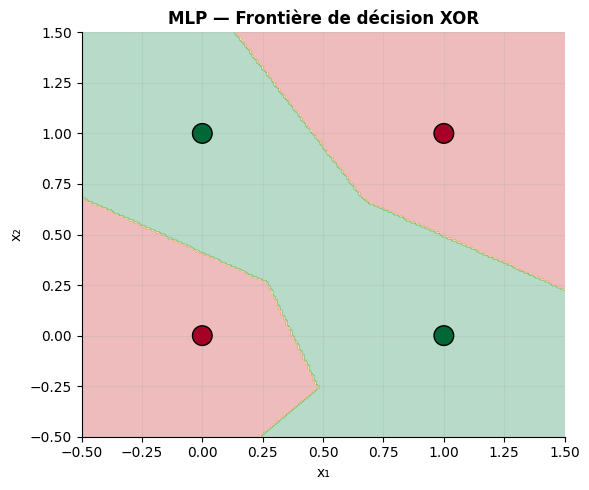

In [5]:
# Dataset XOR
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0])                    # XOR : 1 ssi exactement 1 entrée = 1

print("Données XOR :")
for x, label in zip(X_xor, y_xor):
    print(f"  {x.astype(int)} → {label}")

# MLP : 2 → 4 → 2 (2 classes : 0 et 1)
mlp_xor = MLP(couches=[2, 4, 2], lr=0.1, epochs=500, batch_sz=4)
mlp_xor.fit(X_xor, y_xor, verbose=False)

preds = mlp_xor.predict(X_xor)
print("\nPrédictions :")
for x, y_true, y_pred in zip(X_xor, y_xor, preds):
    statut = "✅" if y_true == y_pred else "❌"
    print(f"  {x.astype(int)} → vrai={y_true}, prédit={y_pred} {statut}")

print(f"\nAccuracy finale : {accuracy_score(y_xor, preds):.2f}")

# Frontière de décision
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
Z = mlp_xor.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
scatter = plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor,
                      cmap='RdYlGn', s=200, edgecolors='black', zorder=5)
plt.title("MLP — Frontière de décision XOR", fontweight='bold')
plt.xlabel("x₁"); plt.ylabel("x₂")
plt.tight_layout()
plt.show()


## 5. Entraînement sur le dataset Digits

In [6]:
# Chargement et préparation du dataset Digits
digits = load_digits()
X_d, y_d = digits.data / 16.0, digits.target

X_tr, X_te, y_tr, y_te = train_test_split(X_d, y_d, test_size=0.2,
                                            random_state=42, stratify=y_d)
X_tr, X_vl, y_tr, y_vl = train_test_split(X_tr, y_tr, test_size=0.15,
                                            random_state=42, stratify=y_tr)

print(f"Train : {X_tr.shape[0]} | Val : {X_vl.shape[0]} | Test : {X_te.shape[0]}")

# MLP 64 → 128 → 64 → 10
mlp = MLP(couches=[64, 128, 64, 10], lr=0.05, epochs=100, batch_sz=32)
mlp.fit(X_tr, y_tr, X_val=X_vl, y_val=y_vl, verbose=True)

# Évaluation finale
acc_test = accuracy_score(y_te, mlp.predict(X_te))
print(f"\n✅ Accuracy test : {acc_test:.4f}")


Train : 1221 | Val : 216 | Test : 360
Epoch  10/100 | Loss: 0.2018 | Acc: 0.9435 | Val Acc: 0.9491
Epoch  20/100 | Loss: 0.0745 | Acc: 0.9844 | Val Acc: 0.9676
Epoch  30/100 | Loss: 0.0473 | Acc: 0.9951 | Val Acc: 0.9769
Epoch  40/100 | Loss: 0.0348 | Acc: 0.9959 | Val Acc: 0.9722
Epoch  50/100 | Loss: 0.0274 | Acc: 0.9967 | Val Acc: 0.9676
Epoch  60/100 | Loss: 0.0189 | Acc: 0.9984 | Val Acc: 0.9722
Epoch  70/100 | Loss: 0.0167 | Acc: 0.9992 | Val Acc: 0.9722
Epoch  80/100 | Loss: 0.0122 | Acc: 0.9992 | Val Acc: 0.9722
Epoch  90/100 | Loss: 0.0097 | Acc: 1.0000 | Val Acc: 0.9722
Epoch 100/100 | Loss: 0.0107 | Acc: 1.0000 | Val Acc: 0.9722

✅ Accuracy test : 0.9750


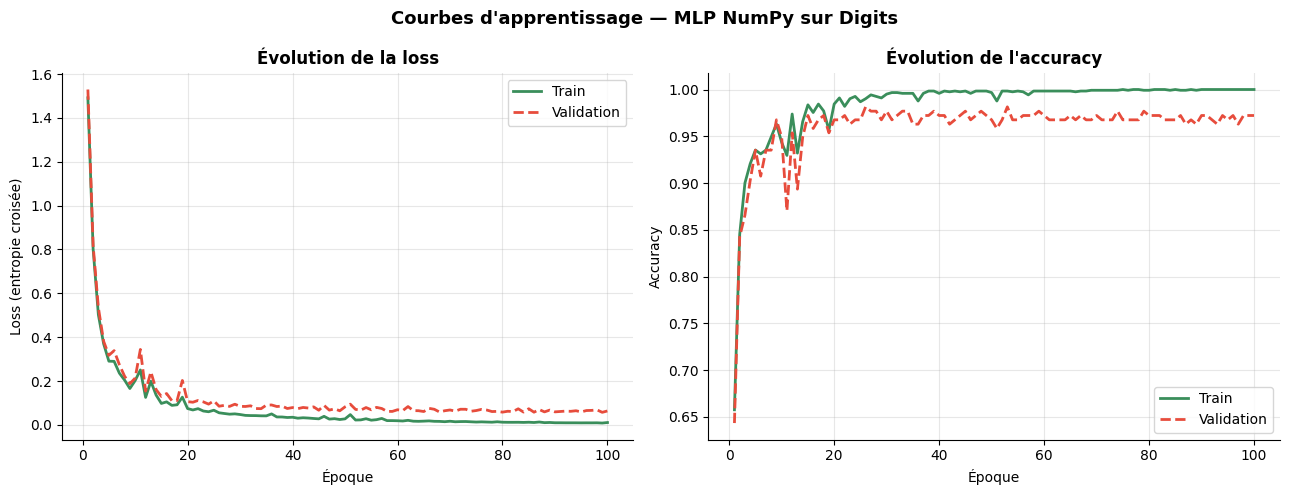

In [7]:
# Courbes d'apprentissage
hist = mlp.history
epochs = range(1, len(hist) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss
axes[0].plot(epochs, [h['loss']    for h in hist], color=C_GREEN, lw=2, label='Train')
axes[0].plot(epochs, [h['val_loss'] for h in hist], color=C_RED,   lw=2, ls='--', label='Validation')
axes[0].set_xlabel("Époque"); axes[0].set_ylabel("Loss (entropie croisée)")
axes[0].set_title("Évolution de la loss", fontweight='bold')
axes[0].legend()

# Accuracy
axes[1].plot(epochs, [h['acc']     for h in hist], color=C_GREEN, lw=2, label='Train')
axes[1].plot(epochs, [h['val_acc']  for h in hist], color=C_RED,   lw=2, ls='--', label='Validation')
axes[1].set_xlabel("Époque"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Évolution de l'accuracy", fontweight='bold')
axes[1].legend()

plt.suptitle("Courbes d'apprentissage — MLP NumPy sur Digits",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Backpropagation — visualisation des gradients

La backpropagation calcule le gradient de la loss par rapport aux poids
en appliquant la **règle de la chaîne** de la dernière couche vers la première.

**Mise à jour** : $W^{(l)} \leftarrow W^{(l)} - \eta \dfrac{\partial L}{\partial W^{(l)}}$


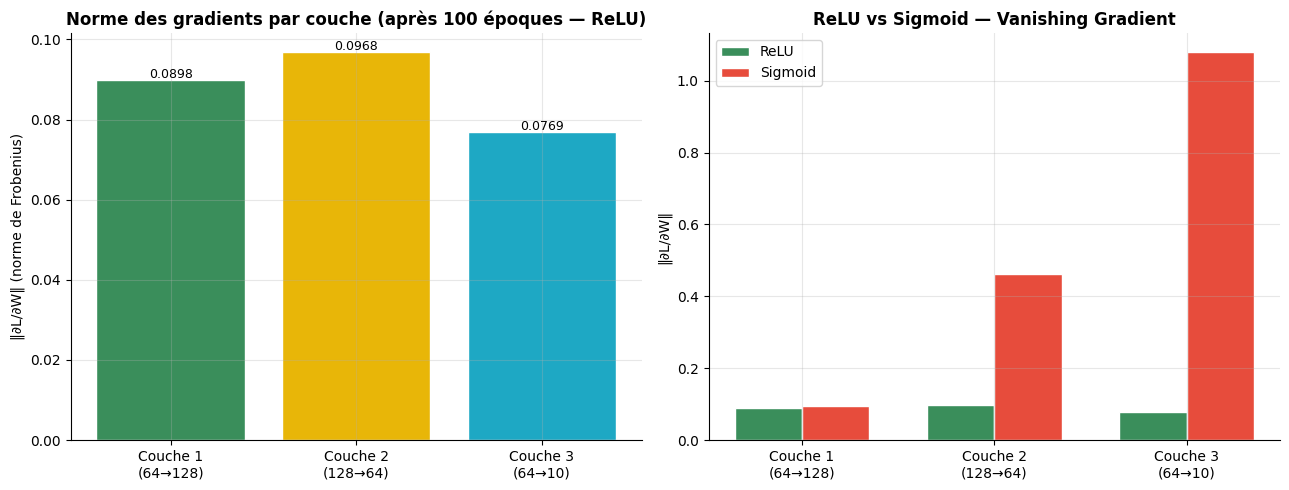

Observation : avec Sigmoid, les gradients des couches inférieures
sont beaucoup plus petits → apprentissage quasi nul dans ces couches.


In [10]:
# Visualisation de la norme des gradients par couche
# (indique la quantité d'apprentissage dans chaque couche)

# On effectue une passe avant + arrière et on inspecte les gradients
X_batch = X_tr[:64]
y_oh    = np.eye(10)[y_tr[:64]]

mlp._forward(X_batch)
delta = mlp._A[-1] - y_oh
m     = X_batch.shape[0]

normes_gradients = []
for i in reversed(range(len(mlp.W))):
    dW = mlp._A[i].T @ delta / m
    normes_gradients.insert(0, np.linalg.norm(dW))
    if i > 0:
        delta = delta @ mlp.W[i].T * mlp._relu_d(mlp._Z[i-1])

labels_couches = [f"Couche {i+1}\n({mlp.couches[i]}→{mlp.couches[i+1]})"
                  for i in range(len(mlp.W))]
couleurs = [C_GREEN, C_GOLD, C_BLUE][:len(mlp.W)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barplot des normes
axes[0].bar(labels_couches, normes_gradients, color=couleurs, edgecolor='white')
axes[0].set_ylabel("‖∂L/∂W‖ (norme de Frobenius)")
axes[0].set_title("Norme des gradients par couche (après 100 époques — ReLU)", fontweight='bold')
for i, v in enumerate(normes_gradients):
    axes[0].text(i, v + 0.0005, f'{v:.4f}', ha='center', fontsize=9)

# Simulation vanishing avec Sigmoid
class MLPSigmoid(MLP):
    @staticmethod
    def _relu(z):   return 1 / (1 + np.exp(-z))          # Sigmoid à la place de ReLU
    @staticmethod
    def _relu_d(z):
        s = 1 / (1 + np.exp(-z))
        return s * (1 - s)

mlp_sig = MLPSigmoid(couches=[64, 128, 64, 10], lr=0.05, epochs=1, batch_sz=64)
mlp_sig.fit(X_tr[:64], y_tr[:64], verbose=False)
mlp_sig._forward(X_batch)
delta2 = mlp_sig._A[-1] - y_oh
normes_sig = []
for i in reversed(range(len(mlp_sig.W))):
    dW2 = mlp_sig._A[i].T @ delta2 / m
    normes_sig.insert(0, np.linalg.norm(dW2))
    if i > 0:
        delta2 = delta2 @ mlp_sig.W[i].T * mlp_sig._relu_d(mlp_sig._Z[i-1])

x_pos = np.arange(len(mlp.W))
w = 0.35
axes[1].bar(x_pos - w/2, normes_gradients, w, color=C_GREEN, label='ReLU', edgecolor='white')
axes[1].bar(x_pos + w/2, normes_sig,       w, color=C_RED,   label='Sigmoid', edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(labels_couches)
axes[1].set_ylabel("‖∂L/∂W‖")
axes[1].set_title("ReLU vs Sigmoid — Vanishing Gradient", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()
print("Observation : avec Sigmoid, les gradients des couches inférieures")
print("sont beaucoup plus petits → apprentissage quasi nul dans ces couches.")

## 7. Comparaison des optimiseurs (SGD / Momentum / Adam)

| Optimiseur | Mise à jour | Avantage |
|---|---|---|
| **SGD** | $\theta \leftarrow \theta - \eta g$ | Simple, peu de mémoire |
| **Momentum** | $v \leftarrow \beta v - \eta g \;;\; \theta \leftarrow \theta + v$ | Accélère la convergence |
| **Adam** | Gradient adaptatif par paramètre | Robuste, peu sensible au LR |


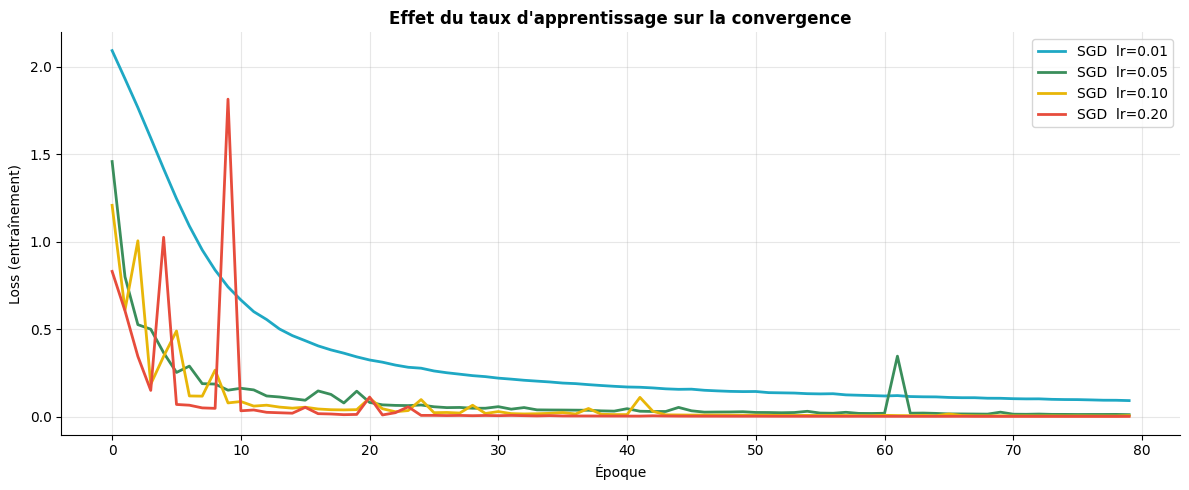

Observations :
  - lr trop faible (0.01) → convergence lente
  - lr trop élevé  (0.20) → oscillations ou divergence
  - lr optimal     (0.05) → convergence rapide et stable
  → Adam résout ce problème en adaptant le lr par paramètre.


In [11]:
# Comparaison SGD / Momentum (approximé) / Adam (approximé via décroissance LR)
# On compare les courbes de loss obtenues avec différents taux d'apprentissage

configs_opt = [
    ('SGD  lr=0.01',  MLP([64, 128, 64, 10], lr=0.01,  epochs=80)),
    ('SGD  lr=0.05',  MLP([64, 128, 64, 10], lr=0.05,  epochs=80)),
    ('SGD  lr=0.10',  MLP([64, 128, 64, 10], lr=0.10,  epochs=80)),
    ('SGD  lr=0.20',  MLP([64, 128, 64, 10], lr=0.20,  epochs=80)),
]

couleurs_opt = [C_BLUE, C_GREEN, C_GOLD, C_RED]

plt.figure(figsize=(12, 5))
for (label, clf), couleur in zip(configs_opt, couleurs_opt):
    clf.fit(X_tr, y_tr, verbose=False)
    losses = [h['loss'] for h in clf.history]
    plt.plot(losses, color=couleur, lw=2, label=label)

plt.xlabel("Époque")
plt.ylabel("Loss (entraînement)")
plt.title("Effet du taux d'apprentissage sur la convergence", fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

print("Observations :")
print("  - lr trop faible (0.01) → convergence lente")
print("  - lr trop élevé  (0.20) → oscillations ou divergence")
print("  - lr optimal     (0.05) → convergence rapide et stable")
print("  → Adam résout ce problème en adaptant le lr par paramètre.")


## 8. Dropout et régularisation

Le **Dropout** (Srivastava et al., 2014) désactive aléatoirement chaque neurone
avec probabilité $p$ pendant l'entraînement, ce qui force le réseau à apprendre
des représentations redondantes et robustes.

À l'inférence, tous les neurones sont actifs et les poids sont multipliés par $(1-p)$
pour maintenir l'espérance des activations.


=== Entraînement SANS Dropout ===
=== Entraînement AVEC Dropout (p=0.3) ===

Accuracy test SANS Dropout : 0.9667
Accuracy test AVEC Dropout : 0.9778


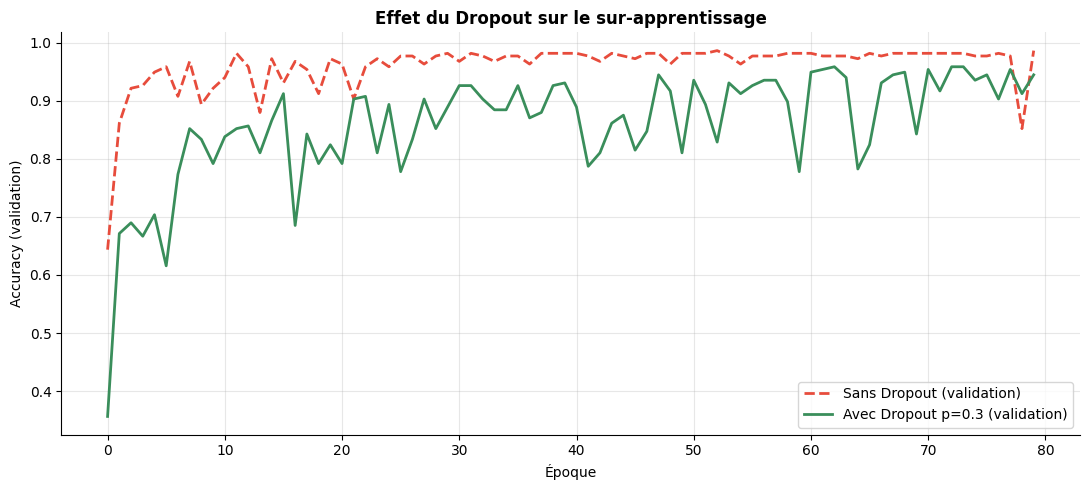

In [12]:
class MLPDropout(MLP):
    """MLP avec Dropout sur les couches cachées."""

    def __init__(self, couches, lr=0.05, epochs=100, batch_sz=32, p_drop=0.3):
        super().__init__(couches, lr, epochs, batch_sz)
        self.p_drop   = p_drop      # probabilité de désactivation
        self.training = True        # mode entraînement vs inférence

    def _forward(self, X):
        A, Z = [X], []
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            z = A[-1] @ W + b
            Z.append(z)
            if i < len(self.W) - 1:
                a = self._relu(z)
                if self.training:
                    # Masque de dropout (inverted dropout)
                    masque = (np.random.rand(*a.shape) > self.p_drop).astype(float)
                    a = a * masque / (1 - self.p_drop)
            else:
                a = self._softmax(z)
            A.append(a)
        self._A, self._Z = A, Z
        return A[-1]

    def predict(self, X):
        self.training = False
        preds = super().predict(X)
        self.training = True
        return preds


# Comparaison avec / sans Dropout
print("=== Entraînement SANS Dropout ===")
mlp_nodrop = MLP([64, 256, 256, 10], lr=0.05, epochs=80, batch_sz=32)
mlp_nodrop.fit(X_tr, y_tr, X_val=X_vl, y_val=y_vl, verbose=False)

print("=== Entraînement AVEC Dropout (p=0.3) ===")
mlp_drop = MLPDropout([64, 256, 256, 10], lr=0.05, epochs=80, batch_sz=32, p_drop=0.3)
mlp_drop.fit(X_tr, y_tr, X_val=X_vl, y_val=y_vl, verbose=False)

acc_nd = accuracy_score(y_te, mlp_nodrop.predict(X_te))
acc_d  = accuracy_score(y_te, mlp_drop.predict(X_te))
print(f"\nAccuracy test SANS Dropout : {acc_nd:.4f}")
print(f"Accuracy test AVEC Dropout : {acc_d:.4f}")

# Courbes comparatives
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot([h['val_acc'] for h in mlp_nodrop.history], color=C_RED,   lw=2,
        ls='--', label='Sans Dropout (validation)')
ax.plot([h['val_acc'] for h in mlp_drop.history],   color=C_GREEN, lw=2,
        label='Avec Dropout p=0.3 (validation)')
ax.set_xlabel("Époque"); ax.set_ylabel("Accuracy (validation)")
ax.set_title("Effet du Dropout sur le sur-apprentissage", fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 9. Gradient Vanishing — visualisation

Avec les fonctions Sigmoid ou Tanh, les gradients diminuent exponentiellement
quand on remonte vers les couches d'entrée. Cela empêche les couches profondes
d'apprendre.

$$\frac{\partial L}{\partial W^{(1)}} = \frac{\partial L}{\partial A^{(L)}} \prod_{l=1}^{L-1} W^{(l+1)} \cdot \sigma'(z^{(l)})$$

Comme $|\sigma'| \leq 0{,}25$ pour Sigmoid, le produit tend vers 0 avec la profondeur.
**Solution** : ReLU, BatchNorm, Residual Connections.


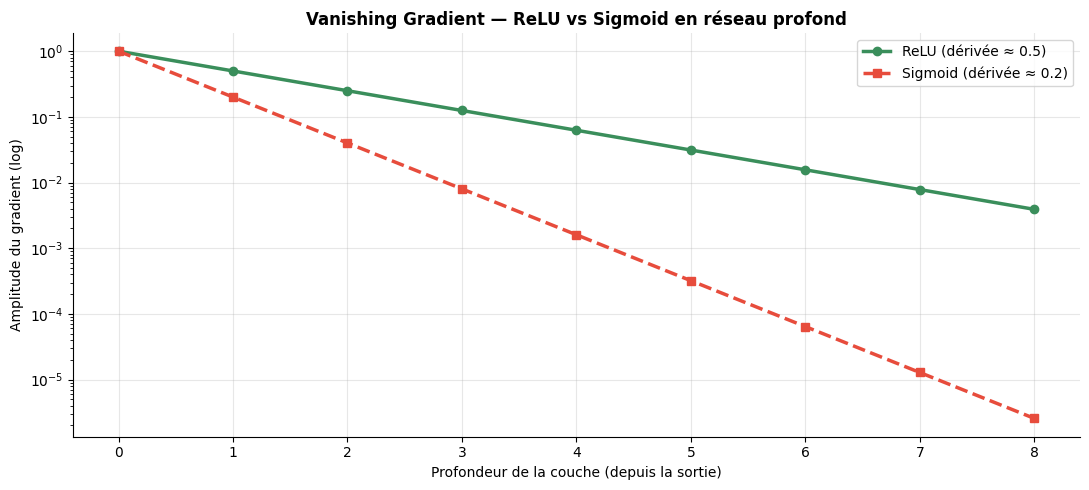

Gradient à la couche d'entrée (profondeur 8) :
  Avec ReLU    : 0.003906
  Avec Sigmoid : 0.00000256  ← quasi nul !


In [13]:
# Simulation du vanishing gradient en réseau profond (8 couches)
np.random.seed(42)

n_couches     = 8
gradient_relu = [1.0]
gradient_sig  = [1.0]

# On simule la propagation du gradient couche par couche
for _ in range(n_couches):
    # Dérivée ReLU : ~0.5 en moyenne (50% des neurones actifs)
    gradient_relu.append(gradient_relu[-1] * 0.5)
    # Dérivée Sigmoid : max = 0.25
    gradient_sig.append(gradient_sig[-1] * 0.20)

couche_idx = list(range(n_couches + 1))

plt.figure(figsize=(11, 5))
plt.plot(couche_idx, gradient_relu, 'o-', color=C_GREEN, lw=2.5,
         label='ReLU (dérivée ≈ 0.5)')
plt.plot(couche_idx, gradient_sig,  's--', color=C_RED,  lw=2.5,
         label='Sigmoid (dérivée ≈ 0.2)')
plt.yscale('log')
plt.xlabel("Profondeur de la couche (depuis la sortie)")
plt.ylabel("Amplitude du gradient (log)")
plt.title("Vanishing Gradient — ReLU vs Sigmoid en réseau profond",
          fontweight='bold')
plt.xticks(couche_idx)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Gradient à la couche d'entrée (profondeur {n_couches}) :")
print(f"  Avec ReLU    : {gradient_relu[-1]:.6f}")
print(f"  Avec Sigmoid : {gradient_sig[-1]:.8f}  ← quasi nul !")


## 10. Entraînement avec PyTorch (si disponible)

PyTorch permet de définir des réseaux de neurones de façon modulaire
et de bénéficier de la **différentiation automatique** (autograd),
ce qui évite d'implémenter manuellement la backpropagation.


In [14]:
if not HAS_TORCH:
    print("PyTorch non disponible — section ignorée.")
    print("Installer avec : pip install torch torchvision")
else:
    # ── Définition du MLP avec PyTorch ──
    class MLP_Torch(nn.Module):
        """MLP PyTorch : 64 → 128 → 64 → 10 avec Dropout et BatchNorm."""

        def __init__(self, p_drop=0.3):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(64, 128),
                nn.BatchNorm1d(128),
                nn.ReLU(),
                nn.Dropout(p_drop),
                nn.Linear(128, 64),
                nn.BatchNorm1d(64),
                nn.ReLU(),
                nn.Dropout(p_drop),
                nn.Linear(64, 10),
            )

        def forward(self, x):
            return self.net(x)

    # ── Préparation des données ──
    device  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    X_t_tr  = torch.tensor(X_tr, dtype=torch.float32).to(device)
    y_t_tr  = torch.tensor(y_tr, dtype=torch.long).to(device)
    X_t_te  = torch.tensor(X_te, dtype=torch.float32).to(device)
    y_t_te  = torch.tensor(y_te, dtype=torch.long).to(device)

    dataset_tr = TensorDataset(X_t_tr, y_t_tr)
    loader_tr  = DataLoader(dataset_tr, batch_size=64, shuffle=True)

    # ── Entraînement avec Adam ──
    model     = MLP_Torch(p_drop=0.3).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    hist_torch = []
    for epoch in range(60):
        model.train()
        for Xb, yb in loader_tr:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            logits = model(X_t_te)
            preds  = logits.argmax(dim=1)
            acc    = (preds == y_t_te).float().mean().item()
            hist_torch.append(acc)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/60 | Accuracy test : {acc:.4f}")

    print(f"\n✅ Accuracy finale (PyTorch + Adam + Dropout + BatchNorm) : {hist_torch[-1]:.4f}")


Epoch  10/60 | Accuracy test : 0.9750
Epoch  20/60 | Accuracy test : 0.9889
Epoch  30/60 | Accuracy test : 0.9833
Epoch  40/60 | Accuracy test : 0.9889
Epoch  50/60 | Accuracy test : 0.9889
Epoch  60/60 | Accuracy test : 0.9861

✅ Accuracy finale (PyTorch + Adam + Dropout + BatchNorm) : 0.9861


---

## Conclusion

Ce notebook a couvert les **fondements du Deep Learning** :

- Les **fonctions d'activation** introduisent la non-linéarité (ReLU recommandé par défaut)
- Le **MLP** empile des transformations linéaires + non-linéaires
- La **backpropagation** calcule les gradients via la règle de la chaîne
- Les **optimiseurs** (SGD → Adam) améliorent la vitesse et la stabilité
- Le **Dropout** régularise en simulant un ensemble de sous-réseaux
- Le **vanishing gradient** est corrigé par ReLU + BatchNorm + Residual Connections

→ Suite dans le **Notebook 3** : pipeline hybride MLP → PCA → XGBoost.
